# 14.1. 오비탈이 섞이는 조건

In [1]:
import numpy as np


def S(R):
    return np.exp(-R) * (1 + R + R**2 / 3)


def H_AA(R):
    return -0.5 + np.exp(-2 * R) * (1 + 1 / R)


def H_AB(R):
    return -0.5 * S(R) - np.exp(-R) * (1 + R) + S(R) / R


print(f"{'R':>6} {'alpha':>8} {'beta':>8} {'S':>8}")
for R in [1.0, 2.0, 2.4935, 3.0, 4.0, 8.0]:
    print(f"{R:6.2f} {H_AA(R):8.4f} {H_AB(R):8.4f} {S(R):8.4f}")

     R    alpha     beta        S
  1.00  -0.2293  -0.3066   0.8584
  2.00  -0.4725  -0.4060   0.5865
  2.49  -0.4904  -0.3341   0.4599
  3.00  -0.4967  -0.2572   0.3485
  4.00  -0.4996  -0.1389   0.1893
  8.00  -0.5000  -0.0068   0.0102


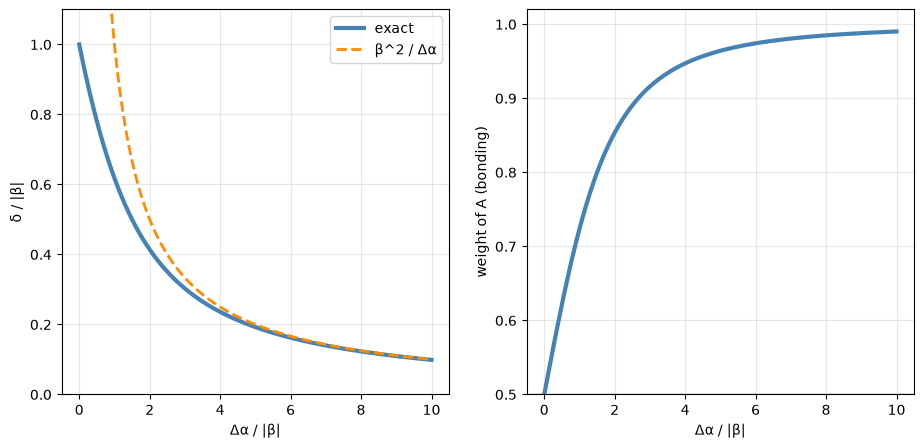

In [2]:
import matplotlib.pyplot as plt


def orbital_mix(a_A, a_B, beta):
    H = np.array([[a_A, beta], [beta, a_B]])
    E, C = np.linalg.eigh(H)
    return E, C


Delta_a = np.linspace(0, 10, 200)
beta = -1.0
delta, c_A_squared = [], []
for x in Delta_a:
    E, C = orbital_mix(0, x, beta)
    delta.append(-E[0])
    c_A_squared.append(C[0, 0] ** 2)


fig, axes = plt.subplots(1, 2, figsize=(11, 5))

ax = axes[0]
ax.plot(Delta_a, delta, lw=3, color="steelblue", label="exact")
ax.plot(Delta_a[10:], beta**2 / Delta_a[10:], ls="--", lw=2, color="darkorange", label="β^2 / Δα")
ax.set_ylim(0, 1.1)
ax.set_xlabel("Δα / |β|")
ax.set_ylabel("δ / |β|")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(Delta_a, c_A_squared, lw=3, color="steelblue")
ax.axhline(0.5, color="gray", lw=1)
ax.set_ylim(0.5, 1.02)
ax.set_xlabel("Δα / |β|")
ax.set_ylabel("weight of A (bonding)")
ax.grid(alpha=0.3)

plt.show()